## Code for plotting temperature and salinity along the transects, as well as T-S diagram

In [33]:
import xarray as xr
import numpy as np
import os
import cmocean
import gsw

import matplotlib as mpl
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
from matplotlib.gridspec import GridSpec

In [2]:
import matplotlib.colors as colors

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_cmap = colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

In [3]:
os.chdir('.../outputs_miscellaneous/Davis_Strait_Transect')

vs = np.load('ANHA4-EJM010_temperature_DavisStrait_2007_2017.npz')
vs = vs['temperature']
temp_vs = np.nanmean(vs, axis=0)

vd = np.load('ANHA4-EJM012_temperature_DavisStrait_2007_2017.npz')
vd = vd['temperature']
temp_vd = np.nanmean(vd, axis=0)

vs = np.load('ANHA4-EJM010_salinity_DavisStrait_2007_2017.npz')
vs = vs['salinity']
sal_vs = np.nanmean(vs, axis=0)

vd = np.load('ANHA4-EJM012_salinity_DavisStrait_2007_2017.npz')
vd = vd['salinity']
sal_vd = np.nanmean(vd, axis=0)

In [4]:
sal_dif_vdvs = sal_vd - sal_vs
temp_dif_vdvs = temp_vd - temp_vs

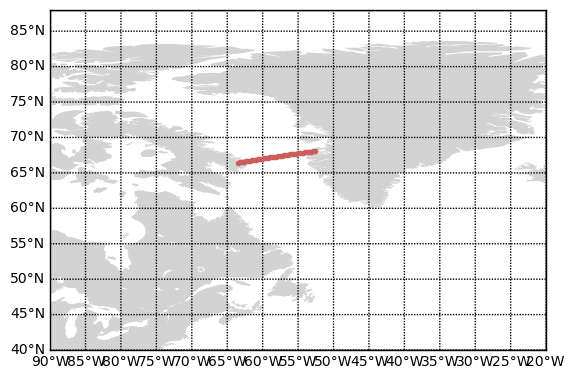

In [77]:
os.chdir('.')

data_mask = xr.open_dataset('ANHA4_mask.nc')

mask = data_mask.variables['tmask']
mask = mask[0][0]

data_grid = xr.open_dataset('.../ANHA4-EJM010_y2017m12d31_gridT.nc')

lat = data_grid.variables['nav_lat_grid_T']
lon = data_grid.variables['nav_lon_grid_T']
lon = np.asarray(lon)
lat = np.asarray(lat)
depth = data_grid.variables['deptht']

#Baffin Bay
slat_bb = 485
slon_bb = np.arange(170, 225) 

#Davis Strait
slat_ds = 440
slon_ds = np.arange(173, 212)

depths = np.arange(0, 35)

s1 = slat_ds # or slat_ds
s2 = slon_ds # or slon_ds

sec = np.copy(mask)
sec[s1, s2] = 5
sec[np.where(sec != 5)] = np.nan

m = Basemap(projection='cyl', llcrnrlon=-90, llcrnrlat=40, urcrnrlon=-20, urcrnrlat=88, resolution = 'l')

m.drawmeridians(np.arange(0,360,5), labels=[0, 0, 0, 1])
m.drawparallels(np.arange(-90,90,5), labels=[1, 0, 0, 0])
m.drawmapboundary()
m.fillcontinents(color='lightgray')

lons = lon[s1,s2]
lats = lat[s1,s2]

x, y = m(lons,lats)

m.plot(x, y, marker=".",color='indianred')

plt.show()

In [79]:
sec_lat = lat[ s1, s2]
sec_lon = lon[ s1, s2]
sec_depth = depth[depths]

tmask = data_mask.variables['tmask']
tmask = tmask[0, 0:len(sec_depth),s1, s2]

mask = np.zeros(np.shape(tmask))

for i in range(0, len(tmask)):
    for j in range(0, len(tmask[0])):
        if tmask[i][j] == np.float32(1):
            mask[i][j] = np.nan

In [80]:
xp, yp = np.meshgrid(sec_lon, sec_depth)

In [82]:
sal_vs = np.where(sal_vs == 0, np.nan, sal_vs)
sal_vd = np.where(sal_vd == 0, np.nan, sal_vd)

temp_vs = np.where(temp_vs == 0, np.nan, temp_vs)
temp_vd = np.where(temp_vd == 0, np.nan, temp_vd)

sal_dif_vdvs = np.where(sal_dif_vdvs == 0, np.nan, sal_dif_vdvs)
temp_dif_vdvs = np.where(temp_dif_vdvs == 0, np.nan, temp_dif_vdvs)

In [83]:
np.shape(xp)

(35, 39)

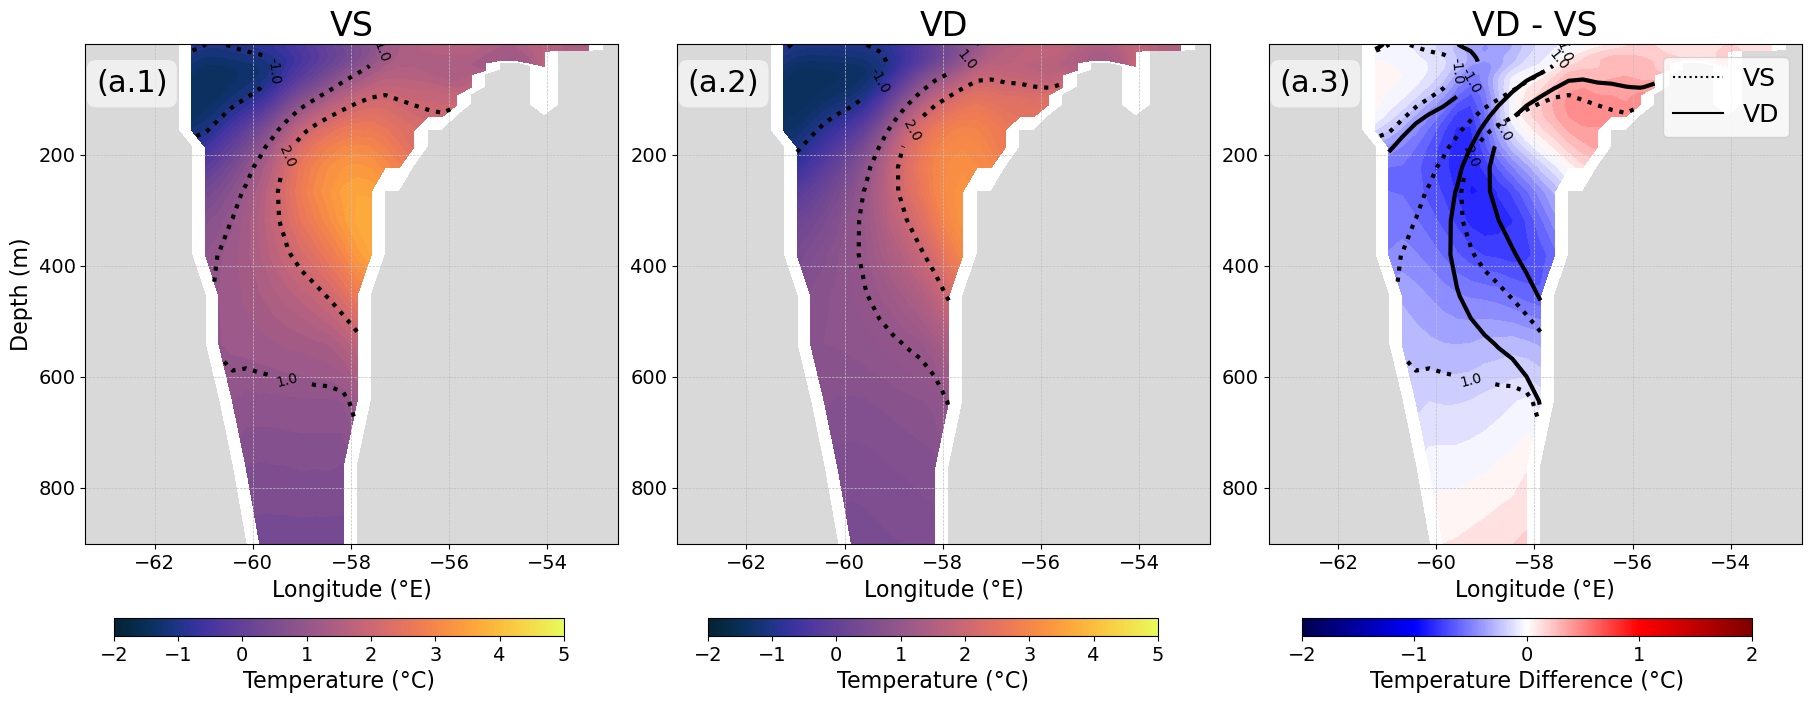

In [84]:

vmin = -2 
vmax = 5
levels = 50
cmap = cmocean.cm.thermal
contour_cmap = truncate_colormap(plt.get_cmap('Greys'), minval=0.4, maxval=1, n=100)

contour_levels = [-1, 1, 2] #for Davis Strait
#contour_levels = [-1, 0.1, 0.5, 1] #for Baffin bay

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(18, 6), constrained_layout=True)

data_list = [temp_vs, temp_vd, temp_dif_vdvs]
titles = ['VS', 'VD', 'VD - VS']
cmaps = [cmap, cmap, 'seismic']
vmins = [vmin, vmin, -2]
vmaxs = [vmax, vmax, 2]
levels_list = [levels, levels, 20]

for i in range(3):
    cf = ax[i].contourf(xp, yp, data_list[i], levels=levels_list[i], 
                        vmin=vmins[i], vmax=vmaxs[i], cmap=cmaps[i])
    ax[i].contourf(xp, yp, mask, cmap='Greys')

    if i < 2:
        cont = ax[i].contour(xp, yp, data_list[i], levels=contour_levels,
                             colors = 'black', linestyles='dotted', linewidths=3)
        plt.clabel(cont, fmt='%1.1f', fontsize=10)
    else:
        cont_vs = ax[i].contour(xp, yp, temp_vs, levels=contour_levels,
                                colors = 'black', linestyles='dotted', linewidths=3)
        plt.clabel(cont_vs, fmt='%1.1f', fontsize=10)
        cont_vd = ax[i].contour(xp, yp, temp_vd, levels=contour_levels,
                                colors = 'black', linestyles='solid', linewidths=3)
        plt.clabel(cont_vd, fmt='%1.1f', fontsize=10)
        ax[i].legend([Line2D([0], [0], color='black', linestyle=':'),
                      Line2D([0], [0], color='black', linestyle='-')],
                     ['VS', 'VD'], fontsize=18, loc='upper right')

    ax[i].set_title(titles[i], fontsize=24)
    ax[i].set_ylim(max(sec_depth), min(depth))
    ax[i].grid(color='silver', linestyle='--', linewidth=0.5)
    ax[i].set_xlabel('Longitude (\u00B0E)', fontsize=16)
    ax[i].tick_params(axis='both', which='major', labelsize=14) 

    
    if i == 0:
        ax[i].set_ylabel('Depth (m)', fontsize=16)

cbar_height = 0.03
cbar_y = -0.05

for i in range(3):
    cax = fig.add_axes([0.06 + i*0.33, cbar_y, 0.25, cbar_height]) 
    norm = mpl.colors.Normalize(vmin=vmins[i], vmax=vmaxs[i])
    cb = mpl.colorbar.ColorbarBase(cax, cmap=cmaps[i], norm=norm, orientation='horizontal')
    cb.ax.tick_params(labelsize=14) 
    if i < 2:
        cb.set_label('Temperature (\u00B0C)', fontsize=16)
    else:
        cb.set_label('Temperature Difference (\u00B0C)', fontsize=16)
        
        
labels = ['a.1', 'a.2', 'a.3']

for i, ax in enumerate(ax):
    
    ax.text(0.02, 0.95, f'({labels[i]})', transform=ax.transAxes,
            fontsize=22, va='top', ha='left', 
           bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.3', alpha=0.6))


plt.show()


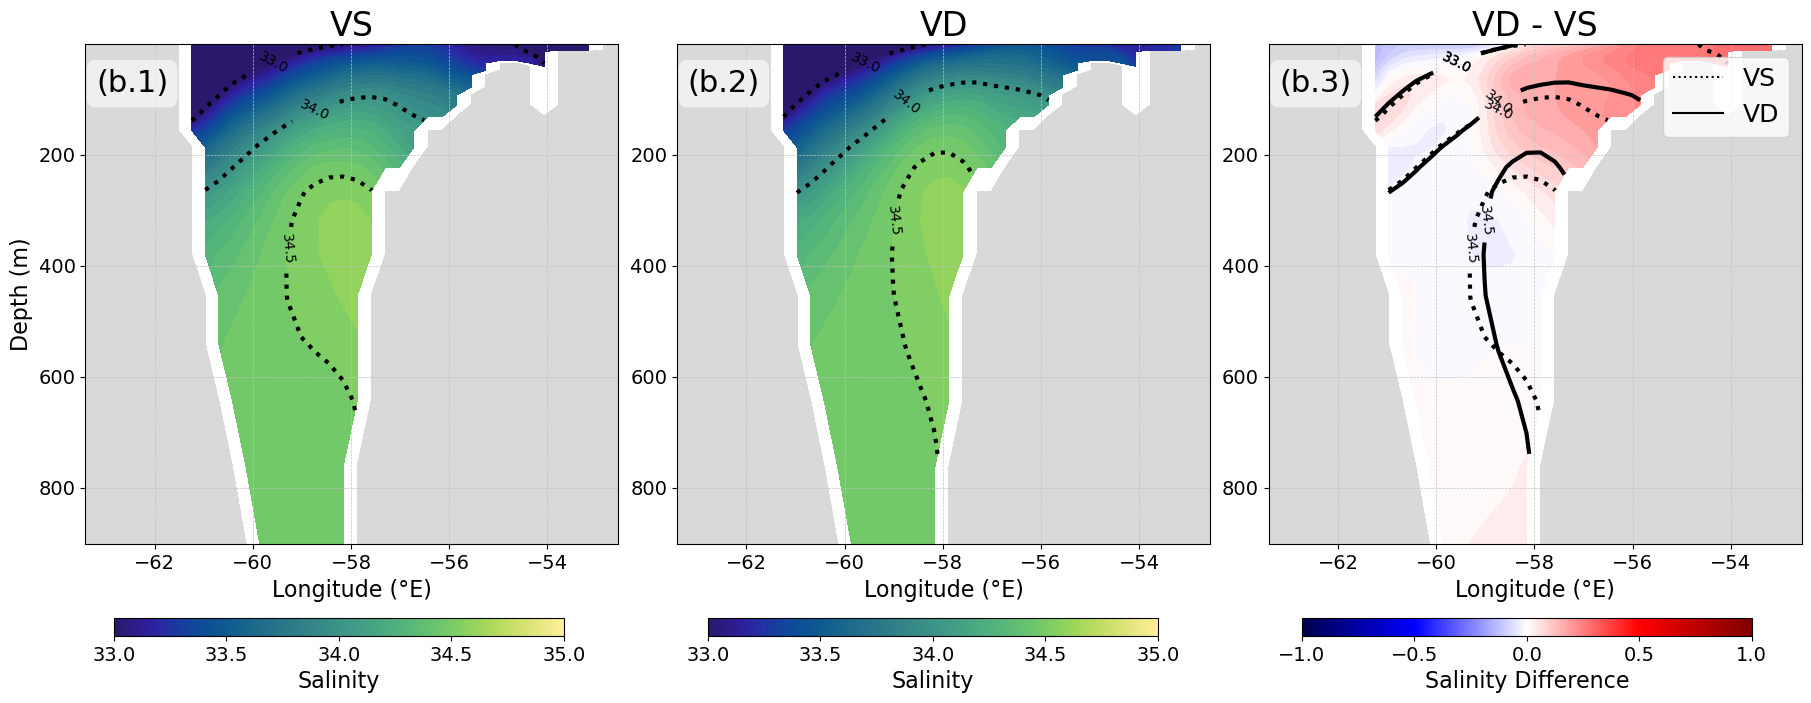

In [29]:
vmin = 33
vmax = 35
levels = 50
cmap = cmocean.cm.haline
contour_cmap = truncate_colormap(plt.get_cmap('Greys'), minval=0.4, maxval=1, n=100)

contour_levels = [33, 34, 34.5] #for Davis Strait
#contour_levels = [33, 34, 34.3, 34.4] #for Baffin bay

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(18, 6), constrained_layout=True)

data_list = [sal_vs, sal_vd, sal_dif_vdvs]
titles = ['VS', 'VD', 'VD - VS']
cmaps = [cmap, cmap, 'seismic']
vmins = [vmin, vmin, -1]
vmaxs = [vmax, vmax, 1]
levels_list = [levels, levels, 20]

for i in range(3):
    cf = ax[i].contourf(xp, yp, data_list[i], levels=levels_list[i], 
                        vmin=vmins[i], vmax=vmaxs[i], cmap=cmaps[i])
    ax[i].contourf(xp, yp, mask, cmap='Greys')

    if i < 2:
        cont = ax[i].contour(xp, yp, data_list[i], levels=contour_levels,
                             colors = 'black', linestyles='dotted', linewidths=3)
        plt.clabel(cont, fmt='%1.1f', fontsize=10)
    else:
        cont_vs = ax[i].contour(xp, yp, sal_vs, levels=contour_levels,
                                colors = 'black', linestyles='dotted', linewidths=3)
        plt.clabel(cont_vs, fmt='%1.1f', fontsize=10)
        cont_vd = ax[i].contour(xp, yp, sal_vd, levels=contour_levels,
                                colors = 'black', linestyles='solid', linewidths=3)
        plt.clabel(cont_vd, fmt='%1.1f', fontsize=10)
        ax[i].legend([Line2D([0], [0], color='black', linestyle=':'),
                      Line2D([0], [0], color='black', linestyle='-')],
                     ['VS', 'VD'], fontsize=18, loc='upper right')

    ax[i].set_title(titles[i], fontsize=24)
    ax[i].set_ylim(max(sec_depth), min(depth))
    ax[i].grid(color='silver', linestyle='--', linewidth=0.5)
    ax[i].set_xlabel('Longitude (\u00B0E)', fontsize=16)
    ax[i].tick_params(axis='both', which='major', labelsize=14) 

    
    if i == 0:
        ax[i].set_ylabel('Depth (m)', fontsize=16)

cbar_height = 0.03
cbar_y = -0.05

for i in range(3):
    cax = fig.add_axes([0.06 + i*0.33, cbar_y, 0.25, cbar_height]) 
    norm = mpl.colors.Normalize(vmin=vmins[i], vmax=vmaxs[i])
    cb = mpl.colorbar.ColorbarBase(cax, cmap=cmaps[i], norm=norm, orientation='horizontal')
    cb.ax.tick_params(labelsize=14) 
    if i < 2:
        cb.set_label('Salinity', fontsize=16)
    else:
        cb.set_label('Salinity Difference', fontsize=16)
        
labels = ['b.1', 'b.2', 'b.3']

for i, ax in enumerate(ax):
    ax.text(0.02, 0.95, f'({labels[i]})', transform=ax.transAxes, fontsize=22, va='top', ha='left',
            bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.3', alpha=0.6))        

plt.show()


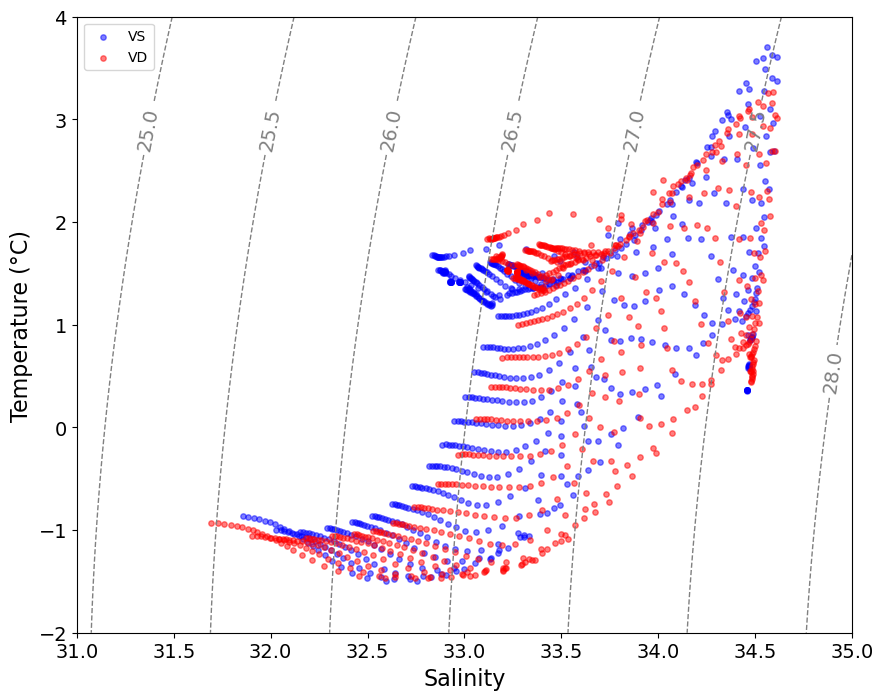

In [89]:
S_grid = np.linspace(31, 35, 100)
T_grid = np.linspace(-2, 4, 100)
Sg, Tg = np.meshgrid(S_grid, T_grid)

SA = gsw.SA_from_SP(Sg, 0, 0, int(np.nanmean(lons)))
CT = gsw.CT_from_t(SA, Tg, 0)

sigma0 = gsw.sigma0(SA, CT)

T_vs = temp_vs.flatten()
S_vs = sal_vs.flatten()

T_vd = temp_vd.flatten()
S_vd = sal_vd.flatten()

plt.figure(figsize=(10, 8))
plt.scatter(S_vs, T_vs, color='blue', s=15, alpha=0.5, label='VS')
plt.scatter(S_vd, T_vd, color='red', s=15, alpha=0.5, label='VD')

cs = plt.contour(Sg, Tg, sigma0, colors='gray', linestyles='--', linewidths=1)
plt.clabel(cs, fmt='%1.1f', fontsize=14)

plt.xlabel('Salinity', fontsize = 16)
plt.ylabel('Temperature (°C)', fontsize = 16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14) 
plt.xlim(31, 35)
plt.legend()

plt.show()


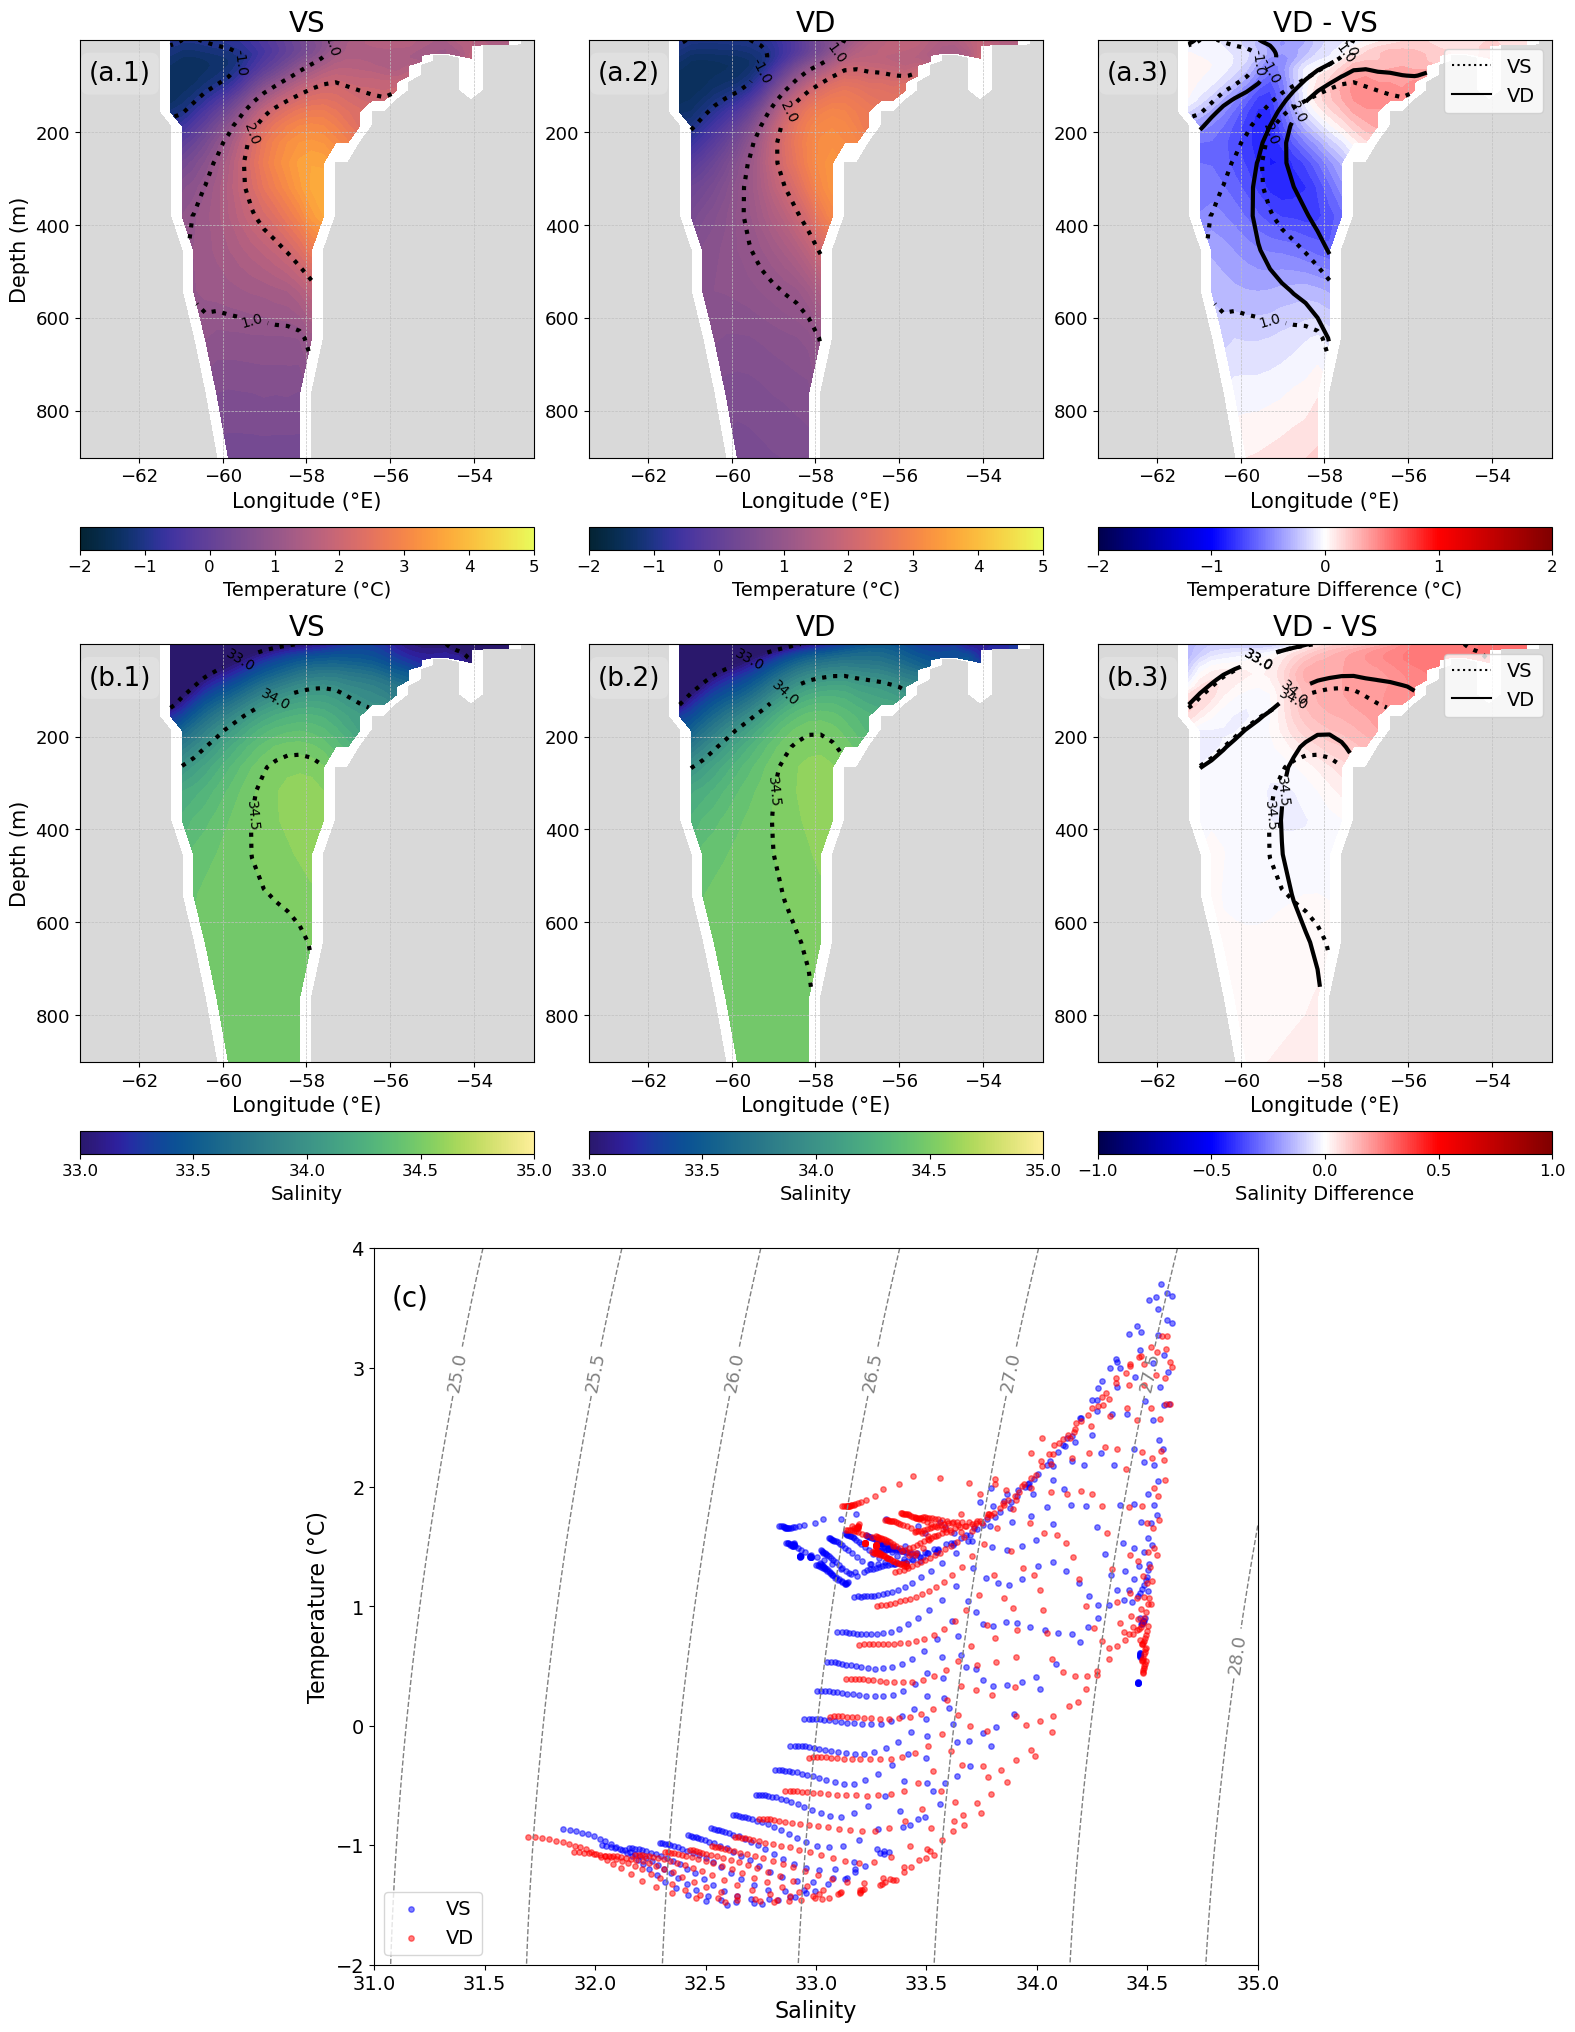

In [90]:
fig = plt.figure(figsize=(19, 25))
gs = GridSpec(3, 3, figure=fig, height_ratios=[2.8, 2.8, 3.5], hspace=0.05, wspace=0.12)

ax_temp = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[0, 2])]

ax_sal = [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1]), fig.add_subplot(gs[1, 2])]

ts_gs = gs[2, :].subgridspec(1, 5, wspace=0)
ax_ts = fig.add_subplot(ts_gs[0, 1:4])

# TEMPERATURE
temp_data = [temp_vs, temp_vd, temp_dif_vdvs]
temp_titles = ['VS', 'VD', 'VD - VS']
temp_cmaps = [cmocean.cm.thermal, cmocean.cm.thermal, 'seismic']
temp_vmins = [-2, -2, -2]
temp_vmaxs = [5, 5, 2]
temp_levels = [50, 50, 20]
temp_contour_levels = [-1, 1, 2]

for i in range(3):
    cf = ax_temp[i].contourf(xp, yp, temp_data[i], levels=temp_levels[i], vmin=temp_vmins[i], vmax=temp_vmaxs[i], cmap=temp_cmaps[i])
    ax_temp[i].contourf(xp, yp, mask, cmap='Greys')

    if i < 2:
        cont = ax_temp[i].contour(xp, yp, temp_data[i], levels=temp_contour_levels, colors='black', linestyles='dotted', linewidths=3)
        ax_temp[i].clabel(cont, fmt='%1.1f', fontsize=10)
    else:
        cont_vs = ax_temp[i].contour(xp, yp, temp_vs, levels=temp_contour_levels, colors='black', linestyles='dotted', linewidths=3)
        ax_temp[i].clabel(cont_vs, fmt='%1.1f', fontsize=10)
        cont_vd = ax_temp[i].contour(xp, yp, temp_vd, levels=temp_contour_levels, colors='black', linestyles='solid', linewidths=3)
        ax_temp[i].clabel(cont_vd, fmt='%1.1f', fontsize=10)
        ax_temp[i].legend([Line2D([0], [0], color='black', linestyle=':'), Line2D([0], [0], color='black', linestyle='-')], ['VS', 'VD'], fontsize=14, loc='upper right')

    ax_temp[i].set_title(temp_titles[i], fontsize=20)
    ax_temp[i].set_ylim(max(sec_depth), min(depth))
    ax_temp[i].grid(color='silver', linestyle='--', linewidth=0.5)
    ax_temp[i].set_xlabel('Longitude (°E)', fontsize=15)
    ax_temp[i].tick_params(axis='both', labelsize=13)

    if i == 0:
        ax_temp[i].set_ylabel('Depth (m)', fontsize=15)

    ax_temp[i].text(0.02, 0.95, f'(a.{i+1})', transform=ax_temp[i].transAxes, fontsize=19, va='top', ha='left', bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.3', alpha=0.2))

for i in range(2):
    norm = mpl.colors.Normalize(vmin=-2, vmax=5)
    cb = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmocean.cm.thermal), ax=ax_temp[i], orientation='horizontal', pad=0.12)
    cb.ax.tick_params(labelsize=12)
    cb.set_label('Temperature (°C)', fontsize=14)
    cb.set_ticks([-2, -1, 0, 1, 2, 3, 4, 5])
    

norm = mpl.colors.Normalize(vmin=-2, vmax=2)
cb = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap='seismic'), ax=ax_temp[2], orientation='horizontal', pad=0.12)
cb.ax.tick_params(labelsize=12)
cb.set_label('Temperature Difference (°C)', fontsize=14)
cb.set_ticks([-2, -1, 0, 1, 2])

# SALINITY
sal_data = [sal_vs, sal_vd, sal_dif_vdvs]
sal_titles = ['VS', 'VD', 'VD - VS']
sal_cmaps = [cmocean.cm.haline, cmocean.cm.haline, 'seismic']
sal_vmins = [33, 33, -1]
sal_vmaxs = [35, 35, 1]
sal_levels = [50, 50, 20]
sal_contour_levels = [33, 34, 34.5]

for i in range(3):
    cf = ax_sal[i].contourf(xp, yp, sal_data[i], levels=sal_levels[i], vmin=sal_vmins[i], vmax=sal_vmaxs[i], cmap=sal_cmaps[i])
    ax_sal[i].contourf(xp, yp, mask, cmap='Greys')

    if i < 2:
        cont = ax_sal[i].contour(xp, yp, sal_data[i], levels=sal_contour_levels, colors='black', linestyles='dotted', linewidths=3)
        ax_sal[i].clabel(cont, fmt='%1.1f', fontsize=10)
    else:
        cont_vs = ax_sal[i].contour(xp, yp, sal_vs, levels=sal_contour_levels, colors='black', linestyles='dotted', linewidths=3)
        ax_sal[i].clabel(cont_vs, fmt='%1.1f', fontsize=10)
        cont_vd = ax_sal[i].contour(xp, yp, sal_vd, levels=sal_contour_levels, colors='black', linestyles='solid', linewidths=3)
        ax_sal[i].clabel(cont_vd, fmt='%1.1f', fontsize=10)
        ax_sal[i].legend([Line2D([0], [0], color='black', linestyle=':'), Line2D([0], [0], color='black', linestyle='-')], ['VS', 'VD'], fontsize=14, loc='upper right')

    ax_sal[i].set_title(sal_titles[i], fontsize=20)
    ax_sal[i].set_ylim(max(sec_depth), min(depth))
    ax_sal[i].grid(color='silver', linestyle='--', linewidth=0.5)
    ax_sal[i].set_xlabel('Longitude (°E)', fontsize=15)
    ax_sal[i].tick_params(axis='both', labelsize=13)

    if i == 0:
        ax_sal[i].set_ylabel('Depth (m)', fontsize=15)

    ax_sal[i].text(0.02, 0.95, f'(b.{i+1})', transform=ax_sal[i].transAxes, fontsize=19, va='top', ha='left', bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.3', alpha=0.2))

for i in range(2):
    norm = mpl.colors.Normalize(vmin=33, vmax=35)
    cb = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmocean.cm.haline), ax=ax_sal[i], orientation='horizontal', pad=0.12)
    cb.ax.tick_params(labelsize=12)
    cb.set_label('Salinity', fontsize=14)
    cb.set_ticks([33, 33.5, 34, 34.5, 35])

norm = mpl.colors.Normalize(vmin=-1, vmax=1)
cb = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap='seismic'), ax=ax_sal[2], orientation='horizontal', pad=0.12)
cb.ax.tick_params(labelsize=12)
cb.set_label('Salinity Difference', fontsize=14)
cb.set_ticks([-1.0, -0.5, 0.0, 0.5, 1.0])

# T-S DIAGRAM
S_grid = np.linspace(31, 35, 100)
T_grid = np.linspace(-2, 4, 100)
Sg, Tg = np.meshgrid(S_grid, T_grid)

SA = gsw.SA_from_SP(Sg, 0, 0, int(np.nanmean(lons)))
CT = gsw.CT_from_t(SA, Tg, 0)
sigma0 = gsw.sigma0(SA, CT)

T_vs = temp_vs.flatten()
S_vs = sal_vs.flatten()
T_vd = temp_vd.flatten()
S_vd = sal_vd.flatten()

ax_ts.scatter(S_vs, T_vs, color='blue', s=15, alpha=0.5, label='VS')
ax_ts.scatter(S_vd, T_vd, color='red', s=15, alpha=0.5, label='VD')

cs = ax_ts.contour(Sg, Tg, sigma0, colors='gray', linestyles='--', linewidths=1)
ax_ts.clabel(cs, fmt='%1.1f', fontsize=13)

ax_ts.set_xlabel('Salinity', fontsize=16)
ax_ts.set_ylabel('Temperature (°C)', fontsize=16)
ax_ts.tick_params(axis='both', labelsize=14)
ax_ts.set_xlim(31, 35)
ax_ts.set_ylim(-2, 4)
ax_ts.legend(fontsize=14)

ax_ts.text(0.02, 0.95, '(c)', transform=ax_ts.transAxes, fontsize=20, va='top', ha='left', bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.3', alpha=0.6))

os.chdir('.../BaffinBay_DavisStrait_Transects/')
plt.savefig('Figure7_Temperature_Salinity_TS_DavisStrait.png', dpi=300, bbox_inches='tight')
plt.show()